# Scryfall Card OCR Fine-Tuning - Granite Docling 258M

This notebook experiments with `ibm-granite/granite-docling-258M` for converting full Magic card images into the structured Scryfall-style text target used by this project.

Unlike the TrOCR baseline, Granite Docling is a vision-language model with chat-style prompting. The training scaffold below uses a fixed extraction prompt, masks prompt tokens in the labels, and trains LoRA adapters on the assistant response only.


In [1]:
from dataclasses import dataclass
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset
from transformers import AutoModelForVision2Seq, AutoProcessor, Trainer, TrainingArguments, set_seed
from peft import LoraConfig, TaskType, get_peft_model

workspace_root = Path.cwd()
if workspace_root.name == "notebooks":
    workspace_root = workspace_root.parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from src.card_ocr.dataset import load_manifest_records, summarize_manifest


In [2]:
manifest_path = workspace_root / "data" / "card_image_text_manifest.jsonl"
records = load_manifest_records(manifest_path, skip_missing_images=True)
summary = summarize_manifest(records)
summary


{'num_records': 8443, 'split_counts': {'train': 6713, 'val': 1680, 'test': 50}}

In [3]:
# distill the target text into something less structured.
# we only want the actual oracle text, not any of the other fields
def read_distilled_oracle_text(
    filepath:str,
    use_printed_text:bool = True,
    get_rarity:bool = False
) -> dict:
    """
    Description
    ----------
    This function reads the supplied filepath and returns a dict where 
    keys are the oracle ID of the card and values are a distilled simple oracle 
    text in the following format:
    <Name>
    <Mana Cost>
    <Type Line>

    <Oracle Text>

    <Power>
    <Toughness>
    <Loyalty>

    <rarity> (optional)

    Inputs
    ----------
    use_printed_text = If true, retrieves all text on the card, even text that is 
        not strictly relevant to tagging (e.g., flavor name, flavor text, reminder text).
    get_rarity = If true, retrieves the rarity. The default is False, as this is 
        not meaningful for downstream tasks.
    """
    # read the file
    with open(filepath, 'r', encoding = 'utf-8') as f:
        cards = json.load(f)

    rarity_map = {'common': 'C', 'uncommon': 'U', 'rare': 'R', 'mythic': 'M'}
    out = {}
    fields = set()
    for card in cards:
        # skip cards that don't have oracle text (like tokens)
        if 'oracle_text' not in card:
            continue

        fields.update(card.keys())

        lines = []
        
        ## === Header Lines ===
        if use_printed_text:
            if card.get('flavor_name'):
                lines.append(card['flavor_name'])

        lines.append(card['name'])

        if card.get('mana_cost'):
            lines.append(card['mana_cost'])

        if use_printed_text:
            if card.get('printed_type_line'):
                lines.append(card['printed_type_line'])
            else:
                if card.get('type_line'):
                    lines.append(card['type_line'])
        else:
            if card.get('type_line'):
                lines.append(card['type_line'])

        ## === Rules Text Lines ===
        if use_printed_text:
            if card.get('printed_text'):
                lines.append("")
                lines.append(card['printed_text'].strip())
            else:
                lines.append("")
                lines.append(card['oracle_text'].strip())
            
            if card.get('flavor_text'):
                lines.append("")
                lines.append(card['flavor_text'].strip())

        else:
            if card.get('oracle_text'):
                lines.append("")
                lines.append(card['oracle_text'].strip())

        ## === Combat / Planeswalker Stats Lines ===
        stats = []
        if card.get('power'):
            stats.append(card['power'])
        
        if card.get('toughness'):
            stats.append(card['toughness'])

        if card.get('loyalty'):
            stats.append(card['loyalty'])

        if stats:
            lines.append("")
            lines.extend(stats)

        ## === Rarity Line === 
        if get_rarity:
            if card.get('rarity'):
                lines.append("")
                lines.append(rarity_map.get(card['rarity'], card['rarity']))

        out[card['oracle_id']] = "\n".join(lines).strip()

    return out

In [4]:
df = pd.DataFrame(records)
distilled = read_distilled_oracle_text('../data/oracle-cards.json')
df['distilled_text'] = df['oracle_id'].map(distilled)
df.head()


,id,oracle_id,card_name,split,image_path,image_type,image_exists,target_text,tags,distilled_text
0,8079,4317f4f1-d339-4940-b46e-659641035595,Ascended Lawmage,train,/Users/nickcruickshank/Projects/scryfall-llm-s...,png,True,Ascended Lawmage\n Mana Cost = {2}{W}{U...,"[evasion, french vanilla]",Ascended Lawmage\n{2}{W}{U}\nCreature — Vedalk...
1,2740,165c15b2-16be-4bb5-a2d8-a46eaf570579,Kami of Transmutation,train,/Users/nickcruickshank/Projects/scryfall-llm-s...,png,True,Kami of Transmutation\n Mana Cost = {1}...,[modal],Kami of Transmutation\n{1}{W}\nCreature — Spir...
2,4742,278574f6-e083-461b-8bac-52ed51f0cf63,Felidar Umbra,train,/Users/nickcruickshank/Projects/scryfall-llm-s...,png,True,Felidar Umbra\n Mana Cost = {1}{W}\nMan...,"[activated ability, gives lifelink, protects-c...",Felidar Umbra\n{1}{W}\nEnchantment — Aura\n\nE...
3,324,02765930-e15e-4cc1-ac0d-040334a9c5bc,Chainbreaker,train,/Users/nickcruickshank/Projects/scryfall-llm-s...,png,True,Chainbreaker\n Mana Cost = {2}\nMana Va...,"[activated ability, repeatable crime]",Chainbreaker\n{2}\nArtifact Creature — Scarecr...
4,1222,0a029c61-b1de-427b-a8e8-36f3a23f001b,"Tymaret, the Murder King",train,/Users/nickcruickshank/Projects/scryfall-llm-s...,png,True,"Tymaret, the Murder King\n Mana Cost = ...","[activate from graveyard, burn planeswalker, b...","Tymaret, the Murder King\n{B}{R}\nLegendary Cr..."


In [5]:
df['distilled_text'][0]

"Ascended Lawmage\n{2}{W}{U}\nCreature — Vedalken Wizard\n\nFlying\nHexproof (This creature can't be the target of spells or abilities your opponents control.)\n\nA lawmage's runic script is an act of governance given form: legislation written directly onto the air itself.\n\n3\n2"

Ascended Lawmage
Ascended Lawmage
{2}{W}{U}
Creature — Vedalken Wizard

Flying
Hexproof (This creature can't be the target of spells or abilities your opponents control.)

A lawmage's runic script is an act of governance given form: legislation written directly onto the air itself.

3
2


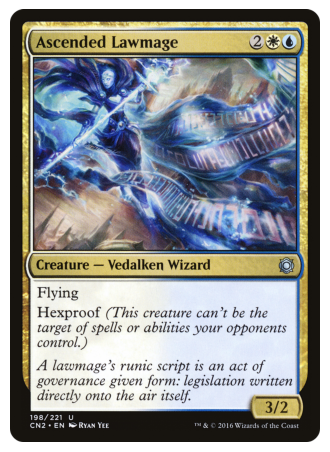

In [6]:
sample_record = next(record for _, record in df.iterrows() if Path(record["image_path"]).exists())
print(sample_record["card_name"])
print(sample_record["distilled_text"][:1200])

with Image.open(sample_record["image_path"]) as sample_image:
    plt.figure(figsize=(4, 6))
    plt.imshow(sample_image)
    plt.axis("off")


In [7]:
@dataclass
class GraniteCardOCRConfig:
    model_name: str = "ibm-granite/granite-docling-258M"
    output_dir: str = "../models/scryfall-card-ocr-granite-docling-258m"
    max_target_length: int = 256
    max_sequence_length: int = 256 # 512 definitely catches everything, 256 is a good start
    generation_max_new_tokens: int = 128 # default 192, but 128 will probably serve
    per_device_train_batch_size: int = 1
    per_device_eval_batch_size: int = 1
    gradient_accumulation_steps: int = 8
    num_train_epochs: float = 3.0
    learning_rate: float = 2e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.05
    logging_steps: int = 1
    save_total_limit: int = 1
    seed: int = 42
    tiny_train_size: int = 4
    tiny_eval_size: int = 4
    lora_r: int = 8 # default 8, 32 to push it
    lora_alpha: int = 16 # default 16, 64 to push it
    lora_dropout: float = 0.05

config = GraniteCardOCRConfig()
set_seed(config.seed)
random.seed(config.seed)
config


GraniteCardOCRConfig(model_name='ibm-granite/granite-docling-258M', output_dir='../models/scryfall-card-ocr-granite-docling-258m', max_target_length=256, max_sequence_length=256, generation_max_new_tokens=128, per_device_train_batch_size=1, per_device_eval_batch_size=1, gradient_accumulation_steps=8, num_train_epochs=3.0, learning_rate=0.0002, weight_decay=0.01, warmup_ratio=0.05, logging_steps=1, save_total_limit=1, seed=42, tiny_train_size=4, tiny_eval_size=4, lora_r=8, lora_alpha=16, lora_dropout=0.05)

## Prompt

The prompt asks for the exact project schema. Keep this stable while comparing models; prompt churn makes baseline comparisons noisy.


In [8]:
# CARD_EXTRACTION_PROMPT = """Extract the Magic: The Gathering card text from this card image.
# Return only the structured text in this exact schema:

# <Card Name>
# Mana Cost = <mana cost or blank>
# Mana Value = <mana value>

# Type Line = <type line>

# Rules Text = <rules text or blank>

# Power = <power if present>
# Toughness = <toughness if present>

# Color Identity = <python-style list>

# Rarity = <rarity>

# Do not include markdown fences, commentary, OCR confidence, or extra fields.
# """.strip()

# print(CARD_EXTRACTION_PROMPT)


In [9]:
# CARD_EXTRACTION_PROMPT = """
# Extract the visible card text.

# Return exactly:

# <Card Name>
# Mana Cost =
# Type Line =
# Rules Text =
# Power =
# Toughness =

# Do not explain.
# """
# print(CARD_EXTRACTION_PROMPT)

In [10]:
# CARD_EXTRACTION_PROMPT = 'Read every piece of visible text from this card.'
# CARD_EXTRACTION_PROMPT = 'Transcribe this Magic card exactly.'
CARD_EXTRACTION_PROMPT = '''
Transcribe this Magic card as plain text.
Do not include bounding boxes, coordinates, locations, XML tags, or markup.
'''

## Pre-Flight EDA

In [11]:
processor = AutoProcessor.from_pretrained(config.model_name)

def get_tokenizer(processor):
    if hasattr(processor, "tokenizer"):
        return processor.tokenizer
    raise AttributeError("Expected the Granite processor to expose a tokenizer.")

tokenizer = get_tokenizer(processor)
if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token = tokenizer.eos_token

target_token_lengths = pd.Series(
    [len(tokenizer(record["distilled_text"]).input_ids) for _, record in df.iterrows()],
    name="target_token_length",
)
target_token_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99])


count    8443.000000
mean       72.547554
std        18.064330
min        14.000000
50%        72.000000
90%        95.000000
95%       102.000000
99%       118.000000
max       397.000000
Name: target_token_length, dtype: float64

In [12]:
num_truncated = int((target_token_lengths > config.max_target_length).sum())
{
    "max_target_length": config.max_target_length,
    "num_targets_over_limit": num_truncated,
    "pct_targets_over_limit": num_truncated / len(target_token_lengths),
}


{'max_target_length': 256,
 'num_targets_over_limit': 1,
 'pct_targets_over_limit': 0.00011844131232974062}

In [13]:
image_sizes = []
for record in random.sample(records, min(200, len(records))):
    with Image.open(record["image_path"]) as image:
        image_sizes.append(image.size)

pd.DataFrame(image_sizes, columns=["width", "height"]).describe()


,width,height
count,200.0,200.0
mean,745.0,1040.0
std,0.0,0.0
min,745.0,1040.0
25%,745.0,1040.0
50%,745.0,1040.0
75%,745.0,1040.0
max,745.0,1040.0


## Baseline Granite Docling Inference

In [14]:
def get_device_and_dtype():
    if torch.backends.mps.is_available():
        return torch.device("mps"), torch.float16
    if torch.cuda.is_available():
        return torch.device("cuda"), torch.float16
    return torch.device("cpu"), torch.float32

baseline_device, baseline_dtype = get_device_and_dtype()
if baseline_dtype == torch.float16:
    # replace with bfloat16 if availble, otherwise proceed with float16
    try:
        baseline_dtype = torch.bfloat16
    except:
        pass
baseline_device, baseline_dtype


(device(type='mps'), torch.bfloat16)

In [15]:
baseline_model = AutoModelForVision2Seq.from_pretrained(
    config.model_name,
    torch_dtype=baseline_dtype,
)
baseline_model.to(baseline_device)
baseline_model.eval()


/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_featur

In [16]:
# # pass model to peft
# peft_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     lora_dropout=0.05,
#     bias="none",
#     task_type="SEQ_2_SEQ_LM",
#     target_modules=[
#         "q_proj",
#         "k_proj",
#         "v_proj",
#         "o_proj",
#     ]
# )

# peft_model = get_peft_model(baseline_model, peft_config)
# peft_model.print_trainable_parameters()
# # for name, param in peft_model.named_parameters():
# #     if param.requires_grad:
# #         print(name, param.shape)

In [17]:
def build_messages(prompt, target_text=None):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }
    ]
    if target_text is not None:
        messages.append(
            {
                "role": "assistant",
                "content": [{"type": "text", "text": target_text}],
            }
        )
    return messages


def apply_chat_template(processor, messages, add_generation_prompt=False):
    return processor.apply_chat_template(
        messages,
        add_generation_prompt=add_generation_prompt,
        tokenize=False,
    )


def run_granite_ocr(
        record, 
        model=baseline_model, 
        processor=processor,
        resize_height = 384 # starting at 512, try [384 and 448 too]
):
    with Image.open(record["image_path"]) as image:
        image = image.convert("RGB")
        # reduce size to help speed up training
        image = image.resize(
            (int(image.width * resize_height / image.height), resize_height)
        )

    prompt_text = apply_chat_template(
        processor,
        build_messages(CARD_EXTRACTION_PROMPT),
        add_generation_prompt=True,
    )
    # print(f'[debug 01] prompt text: {prompt_text}')

    inputs = processor(
        text=[prompt_text],
        images=[image],
        return_tensors="pt",
    )
    inputs = {key: value.to(baseline_device) for key, value in inputs.items()}
    qc = {k: v.shape for k, v in inputs.items()}
    # print(f'[debug 02] inputs: {qc}')

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=config.generation_max_new_tokens,
            do_sample=False,
        )
        # print(f'[debug 03] generated_ids: {generated_ids}')

    prompt_length = inputs["input_ids"].shape[1]
    generated_ids = generated_ids[:, prompt_length:]
    # print(f'[debug 04] generated_ids after removing prompt: {generated_ids}')

    pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    # print(f'[debug 05] pred: {pred}')

    return pred


In [18]:
# from tqdm import tqdm
# baseline_records = random.sample(
#     [record for _, record in df.iterrows() if Path(record["image_path"]).exists()],
#     min(3, len(df)),
# )
# len(baseline_records)

In [19]:
# baseline_rows = []
# progress_bar = tqdm(baseline_records, desc="Running Granite OCR on baseline records")
# for record in baseline_records:
#     # print(record)
#     pred = run_granite_ocr(record)
#     baseline_rows.append(
#         {
#             "card_name": record["card_name"],
#             "split": record["split"],
#             "target_text": record["distilled_text"],
#             "base_prediction": pred,
#         }
#     )
#     progress_bar.update(1)

# baseline_df = pd.DataFrame(baseline_rows)
# baseline_df[["card_name", "split", "target_text", "base_prediction"]]

In [20]:
# for index, row in baseline_df.iterrows():
#     header = f'=== Card: {row["card_name"]} ==='
#     print(f'\n{header}\n')
#     print('-' * 10)
#     print(f'Target Text:\n{row["target_text"]}\n')
#     print('-' * 10)
#     print(f'Base Prediction:\n{row["base_prediction"]}\n')
#     print('-' * 10)
#     print(f'{"=" * len(header)}\n')

## Tiny Overfit Scaffold

Start here before any full training run. On a 16 GB Mac mini, keep the tiny run very small until you know memory behavior. The collator masks the user prompt and trains only on the assistant target text.


In [21]:
custom_data = df.to_dict(orient="records")
class GraniteCardOCRDataset(Dataset):
    def __init__(self, custom_data):
        self.records = custom_data

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        with Image.open(record["image_path"]) as image:
            image = image.convert("RGB")
        return {
            "image": image,
            "target_text": record["distilled_text"],
            "card_name": record["card_name"],
        }


class GraniteCardOCRCollator:
    def __init__(self, processor, prompt, max_sequence_length):
        self.processor = processor
        self.prompt = prompt
        self.max_sequence_length = max_sequence_length
        self.tokenizer = get_tokenizer(processor)

    def __call__(self, features):
        images = [feature["image"] for feature in features]
        prompt_texts = [
            apply_chat_template(
                self.processor,
                build_messages(self.prompt),
                add_generation_prompt=True,
            )
            for _ in features
        ]
        full_texts = [
            apply_chat_template(
                self.processor,
                build_messages(self.prompt, feature["target_text"]),
                add_generation_prompt=False,
            )
            for feature in features
        ]

        batch = self.processor(
            text=full_texts,
            images=images,
            padding=True,
            truncation=False,
            max_length=self.max_sequence_length,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()

        for row_idx, prompt_text in enumerate(prompt_texts):
            prompt_ids = self.tokenizer(
                prompt_text,
                add_special_tokens=False,
                truncation=False,
                max_length=self.max_sequence_length,
            ).input_ids
            prompt_len = min(len(prompt_ids), labels.shape[1])
            labels[row_idx, :prompt_len] = -100

        if self.tokenizer.pad_token_id is not None:
            labels[labels == self.tokenizer.pad_token_id] = -100

        batch["labels"] = labels
        return batch


In [22]:
train_records = [record for record in custom_data if record["split"] == "train"]
eval_records = [record for record in custom_data if record["split"] == "val"]

# tiny_train_records = train_records[: config.tiny_train_size]
# tiny_eval_records = eval_records[: config.tiny_eval_size]

# # quick test of huggingface upload
# train_records = train_records[:10]
# eval_records = eval_records[:3]

train_dataset = GraniteCardOCRDataset(train_records)
eval_dataset = GraniteCardOCRDataset(eval_records)
collator = GraniteCardOCRCollator(processor, CARD_EXTRACTION_PROMPT, config.max_sequence_length)

# batch = collator([tiny_train_dataset[0]])
# {k: tuple(v.shape) for k, v in batch.items() if hasattr(v, "shape")}


In [23]:
# for name, layer in baseline_model.named_parameters():
#     if layer.requires_grad:
#         print(name)

In [24]:
def discover_lora_targets(model):
    """only focuses on the text decoding layers, not the image encoder layers"""

    suffixes = (
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    )

    # matches = set()
    # for module_name, module in model.named_modules():
    #     if not isinstance(module, torch.nn.Linear):
    #         continue
    #     leaf_name = module_name.split(".")[-1]
    #     if leaf_name.endswith(suffixes):
    #         matches.add(leaf_name)
    # return sorted(matches)

    targets = []
    for module_name, module in model.named_modules():
        if not isinstance(module, torch.nn.Linear):
            continue

        if not module_name.startswith('model.text_model.layers'):
            continue
        
        if module_name.endswith(suffixes):
            targets.append(module_name)

    return sorted(targets)



def build_lora_model():
    model = AutoModelForVision2Seq.from_pretrained(
        config.model_name,
        torch_dtype=baseline_dtype,
    )
    if hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = False

    target_modules = discover_lora_targets(model)
    print("LoRA target modules:", target_modules)
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=config.lora_r,
        lora_alpha=config.lora_alpha,
        lora_dropout=config.lora_dropout,
        bias="none",
        # target_modules=target_modules,
        target_modules = ['q_proj', 'v_proj'], # 'k_proj', 'o_proj' contribute less
        exclude_modules = ['vision_model']
    )
    model = get_peft_model(model, lora_config)
    model.to(baseline_device)
    model.print_trainable_parameters()
    return model

lora_model = build_lora_model()


/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


LoRA target modules: ['model.text_model.layers.0.self_attn.k_proj', 'model.text_model.layers.0.self_attn.o_proj', 'model.text_model.layers.0.self_attn.q_proj', 'model.text_model.layers.0.self_attn.v_proj', 'model.text_model.layers.1.self_attn.k_proj', 'model.text_model.layers.1.self_attn.o_proj', 'model.text_model.layers.1.self_attn.q_proj', 'model.text_model.layers.1.self_attn.v_proj', 'model.text_model.layers.10.self_attn.k_proj', 'model.text_model.layers.10.self_attn.o_proj', 'model.text_model.layers.10.self_attn.q_proj', 'model.text_model.layers.10.self_attn.v_proj', 'model.text_model.layers.11.self_attn.k_proj', 'model.text_model.layers.11.self_attn.o_proj', 'model.text_model.layers.11.self_attn.q_proj', 'model.text_model.layers.11.self_attn.v_proj', 'model.text_model.layers.12.self_attn.k_proj', 'model.text_model.layers.12.self_attn.o_proj', 'model.text_model.layers.12.self_attn.q_proj', 'model.text_model.layers.12.self_attn.v_proj', 'model.text_model.layers.13.self_attn.k_proj',

In [25]:
training_args = TrainingArguments(
    output_dir=config.output_dir,
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=config.per_device_train_batch_size,
    per_device_eval_batch_size=config.per_device_eval_batch_size,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
    num_train_epochs=config.num_train_epochs,
    learning_rate=config.learning_rate,
    weight_decay=config.weight_decay,
    warmup_ratio=config.warmup_ratio,
    logging_steps=config.logging_steps,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=config.save_total_limit,
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=0, # 0 is safe on CUDA, 2 may help but not much
    fp16=False,
    bf16=False,
)

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collator,
    processing_class=processor,
)
trainer


In [26]:
# # Tiny overfit sanity check. If this is too slow or hits memory pressure, reduce config.tiny_train_size first.
# tiny_overfit_result = trainer.train()
# tiny_overfit_result


## Tiny Overfit Prediction Audit

In [27]:
def run_lora_ocr(record):
    lora_model.eval()
    with Image.open(record["image_path"]) as image:
        image = image.convert("RGB")

    prompt_text = apply_chat_template(
        processor,
        build_messages(CARD_EXTRACTION_PROMPT),
        add_generation_prompt=True,
    )
    inputs = processor(text=[prompt_text], images=[image], return_tensors="pt")
    inputs = {key: value.to(baseline_device) for key, value in inputs.items()}

    with torch.no_grad():
        generated_ids = lora_model.generate(
            **inputs,
            max_new_tokens=config.generation_max_new_tokens,
            do_sample=False,
        )

    prompt_length = inputs["input_ids"].shape[1]
    generated_ids = generated_ids[:, prompt_length:]
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()


def preview_predictions(records_to_preview, sample_size=3):
    rows = []
    for record in records_to_preview[:sample_size]:
        rows.append(
            {
                "card_name": record["card_name"],
                "split": record["split"],
                "target_text": record["distilled_text"],
                "prediction": run_lora_ocr(record),
            }
        )
    return pd.DataFrame(rows)


In [28]:
# train_audit_df = preview_predictions(tiny_train_records, sample_size=3)
# train_audit_df[["card_name", "distilled_text", "prediction"]]


In [29]:
# eval_audit_df = preview_predictions(tiny_eval_records, sample_size=3)
# eval_audit_df[["card_name", "distilled_text", "prediction"]]


In [30]:
# for index, row in train_audit_df.iterrows():
#     header = f'=== Card: {row["card_name"]} ==='
#     print(f'\n{header}\n')
#     print('-' * 10)
#     print(f'Target Text:\n{row["distilled_text"]}\n')
#     print('-' * 10)
#     print(f'Base Prediction:\n{row["prediction"]}\n')
#     print('-' * 10)
#     print(f'{"=" * len(header)}\n')

## Full Training Placeholder

Scale only after the tiny overfit run can memorize its handful of examples. For a Mac mini with 16 GB RAM, increase one thing at a time: target length, train size, epochs, or LoRA rank.


In [ ]:
# Full-dataset sketch. Leave this disabled until the tiny overfit behavior is acceptable.
full_train_dataset = GraniteCardOCRDataset(train_records)
full_eval_dataset = GraniteCardOCRDataset(eval_records)
trainer.train_dataset = full_train_dataset
trainer.eval_dataset = full_eval_dataset
full_train_result = trainer.train()

full_train_result


/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/transformers/tokenization_utils_base.py:2919: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Epoch,Training Loss,Validation Loss


## Save To Huggingface Hub

In [ ]:
# UNCOMMENT TO login to the hugging face
from huggingface_hub import notebook_login
# with open('../huggingface_token.txt', 'r') as f:
#     token = f.read()

notebook_login()

In [ ]:
# UNCOMMENT TO upload to huggingface hub
from huggingface_hub import get_full_repo_name
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
OUTPUT_DIR = 'mtg-ocr'
repo_id = get_full_repo_name(OUTPUT_DIR)
trainer.model.push_to_hub(repo_id)
trainer.tokenizer.push_to_hub(repo_id)